# Banco de prueba — MotorController + GRBL

Notebook para probar las funcionalidades básicas del controlador de motores usando **GRBL 1.1** sobre Arduino UNO + CNC Shield.

La idea es validar, en forma incremental:

- conexión serie
- estado de GRBL
- inicialización
- `Set Home` / `To Home`
- movimientos relativos y absolutos
- `jog` manual estilo `$J=`
- límites lógicos
- barridos de grilla

**Precaución:** comenzar con pasos chicos y velocidades bajas. Verificar que los motores no estén mecánicamente forzados antes de ejecutar movimientos.


## 1. Instalación de dependencias

Ejecutar una sola vez si falta `pyserial`.

In [95]:
# !pip install pyserial

## 2. Importaciones y configuración inicial

Cambiar `PORT` según el sistema:

- Linux / Raspberry Pi: `/dev/ttyUSB0` o `/dev/ttyACM0`
- Windows: `COM3`, `COM4`, `COM5`, etc.

La velocidad típica de GRBL es `115200` baudios.

In [23]:
from pathlib import Path
import json
import time
import serial
from datetime import datetime
from typing import Callable, Optional, Union

# Cambiar según corresponda
PORT = "/dev/ttyUSB0"   # Linux / Raspberry Pi
# PORT = "COM5"         # Windows

BAUDRATE = 115200
TIMEOUT = 2


## 3. Clase `MotorController`

Pegar o mantener aquí la implementación actual de la clase. Esta versión incluye:

- movimientos relativos (`move_relative`)
- movimientos absolutos (`move_absolute`)
- jog manual (`jog` / `jog_cancel`)
- home lógico (`set_home` / `go_home`)
- límites lógicos
- barrido de grilla (`scan_grid`)

Si ya tenés la clase en un archivo `.py`, podés reemplazar esta celda por un import.

In [24]:
class MotorController:
    """
    Controlador de motores basado en GRBL por puerto serie.

    Modos principales:
    - move_relative / move_absolute: movimientos determinísticos con G1.
    - jog / jog_cancel: movimiento manual tipo joystick usando $J=.

    Incluye home lógico, persistencia de posición, historial de eventos,
    límites lógicos y barridos en grilla.
    """

    STATE_FILE = Path("motor_state.json")
    HISTORY_FILE = Path("motor_history.json")

    def __init__(self, ser: serial.Serial, axis_map: Optional[dict] = None):
        
        # Puerto serie ya inicializado y abierto 
        # (ej: serial.Serial(PORT, BAUDRATE, timeout=TIMEOUT))
        self.ser = ser

        # Ejes lógicos -> ejes físicos GRBL
        # Por defecto, mapea x->X, y->Z, z no se usa.
        # Inversion de dirección por signo: 
        #    1 para normal, 
        #   -1 para invertir sentido.
        self.axis_map = axis_map or {
            "x": ("X", 1),  # eje lógico x -> eje GRBL X
            "y": ("Z", 1),   # eje lógico y -> eje GRBL Z
            "z": (None, 1),  # eje lógico z no se usa por ahora
        }

        self.position = {"x": 0.0, "y": 0.0, "z": 0.0}
        self.home = {"x": 0.0, "y": 0.0, "z": 0.0}

        self.limits = {
            "x_min": -0.5,
            "x_max":  0.5,
            "y_min": -0.5,
            "y_max":  0.5,
            "z_min": -0.2,
            "z_max":  0.2,
        }
        self.limits_enabled = True

        self.load_state()

    def _axis(self, logical_axis: str, value: float) -> str | None:
        real_axis = self.axis_map.get(logical_axis)

        if real_axis is None:
            return None

        return f"{real_axis}{value:.4f}"

    def set_axis_map(self, axis_map: dict):
        self.axis_map = axis_map

    def _now(self):
        return datetime.utcnow().isoformat(timespec="seconds") + "Z"

    def _readline(self):
        return self.ser.readline().decode(errors="ignore").strip()

    def _log_event(self, event: str, **data):
        row = {"ts": self._now(), "event": event, **data}
        with self.HISTORY_FILE.open("a", encoding="utf-8") as f:
            f.write(json.dumps(row, ensure_ascii=False) + "\n")

    def save_state(self):
        data = {
            "home": self.home,
            "position": self.position,
            "limits": self.limits,
            "limits_enabled": self.limits_enabled,
            "updated_at": self._now(),
        }
        self.STATE_FILE.write_text(json.dumps(data, indent=2, ensure_ascii=False), encoding="utf-8")

    def load_state(self):
        if not self.STATE_FILE.exists():
            return
        try:
            data = json.loads(self.STATE_FILE.read_text(encoding="utf-8"))
            self.home = data.get("home", self.home)
            self.position = data.get("position", self.position)
            self.limits = data.get("limits", self.limits)
            self.limits_enabled = data.get("limits_enabled", self.limits_enabled)
        except Exception:
            pass

    def send(self, cmd: str):
        """Envía un comando estándar y espera ok/error."""
        self.ser.write((cmd.strip() + "\n").encode())
        self.ser.flush()
        while True:
            r = self._readline()
            if not r:
                continue
            rl = r.lower()
            if rl.startswith("ok") or rl.startswith("error"):
                return r
            
    def wake_up(self, wait_s: float = 2.0) -> None:
        self.ser.write(b"\r\n\r\n")
        self.ser.flush()
        time.sleep(wait_s)
        self.ser.reset_input_buffer()

    def status(self, timeout_s: float = 1.0) -> str:
        """
        Consulta el estado actual de GRBL usando '?'.
        Devuelve la línea de estado tipo:
        <Idle|MPos:...|FS:...>
        """        
        self.ser.reset_input_buffer()
        self.ser.write(b"?")
        self.ser.flush()

        t0 = time.time()

        while time.time() - t0 < timeout_s:
            line = self.ser.readline().decode(errors="ignore").strip()

            if line.startswith("<") and line.endswith(">"):
                return line

        raise TimeoutError("No se recibió estado GRBL válido.")
    
    

    def initialize(self, feed: float = 80.0):
        self.send("$X")
        self.send("G21")
        self.send(f"F{feed:.2f}")
        self._log_event("initialize", feed=feed)

    def set_limits(self, x_min=None, x_max=None, y_min=None, y_max=None, z_min=None, z_max=None):
        updates = {
            "x_min": x_min, "x_max": x_max,
            "y_min": y_min, "y_max": y_max,
            "z_min": z_min, "z_max": z_max,
        }
        for key, value in updates.items():
            if value is not None:
                self.limits[key] = float(value)
        self._validate_limits_definition()
        self.save_state()
        self._log_event("set_limits", **self.limits)

    def enable_limits(self):
        self.limits_enabled = True
        self.save_state()
        self._log_event("enable_limits")

    def disable_limits(self):
        self.limits_enabled = False
        self.save_state()
        self._log_event("disable_limits")

    def _validate_limits_definition(self):
        if self.limits["x_min"] >= self.limits["x_max"]:
            raise ValueError("Límites inválidos: x_min debe ser menor que x_max")
        if self.limits["y_min"] >= self.limits["y_max"]:
            raise ValueError("Límites inválidos: y_min debe ser menor que y_max")
        if self.limits["z_min"] >= self.limits["z_max"]:
            raise ValueError("Límites inválidos: z_min debe ser menor que z_max")

    def _check_limits(self, x: float, y: float, z: float):
        if not self.limits_enabled:
            return
        errors = []
        if not (self.limits["x_min"] <= x <= self.limits["x_max"]):
            errors.append(f"X={x:.4f} mm fuera de rango [{self.limits['x_min']:.4f}, {self.limits['x_max']:.4f}]")
        if not (self.limits["y_min"] <= y <= self.limits["y_max"]):
            errors.append(f"Y={y:.4f} mm fuera de rango [{self.limits['y_min']:.4f}, {self.limits['y_max']:.4f}]")
        if not (self.limits["z_min"] <= z <= self.limits["z_max"]):
            errors.append(f"Z={z:.4f} mm fuera de rango [{self.limits['z_min']:.4f}, {self.limits['z_max']:.4f}]")
        if errors:
            message = "ALERTA: movimiento fuera de límites operativos. " + " | ".join(errors)
            self._log_event("limit_exceeded", requested_x=x, requested_y=y, requested_z=z, message=message, **self.limits)
            raise ValueError(message)

    def set_home(self):
        # Set home lógico en la posición actual. 
        # No mueve el motor, solo redefine el origen de coordenadas.
        cmd = "G92"
        if self.axis_map["x"][0] is not None:
            axis, _ = self.axis_map["x"]
            cmd += f" {axis}0"

        if self.axis_map["y"][0] is not None:
            axis, _ = self.axis_map["y"]
            cmd += f" {axis}0"

        if self.axis_map["z"][0] is not None:
            axis, _ = self.axis_map["z"]
            cmd += f" {axis}0"

        response = self.send(cmd)

        # Actualiza posición y home lógicos a (0,0,0) en coordenadas del mundo real.
        self.position = {"x": 0.0, "y": 0.0, "z": 0.0}
        self.home = {"x": 0.0, "y": 0.0, "z": 0.0}
        self.save_state()
        self._log_event("set_home", x=0.0, y=0.0, z=0.0)
        
        return response

    def go_home(self, feed: float = 80.0):
        return self.move_absolute(x=self.home["x"], y=self.home["y"], z=self.home["z"], feed=feed)

    def wait_until_idle(self, timeout_s: float = 30.0, poll_s: float = 0.05):
        t0 = time.time()

        while True:
            st = self.status()
            if "Idle" in st:
                return st
            if time.time() - t0 > timeout_s:
                raise TimeoutError(f"Timeout esperando Idle. Último estado: {st}")
            time.sleep(poll_s)

    def move_relative(self, dx: float = 0.0, dy: float = 0.0, dz: float = 0.0, feed: float = 80.0, wait_idle: bool = True) -> str:
        self.send("G91") # Modo relativo
        self.send(f"F{feed:.2f}")

        target_x = self.position["x"] + dx
        target_y = self.position["y"] + dy
        target_z = self.position["z"] + dz
        self._check_limits(target_x, target_y, target_z)

        cmd = "G1"
        if dx != 0.0 and self.axis_map["x"][0] is not None:
            axis, sign = self.axis_map["x"]
            cmd += f" {axis}{sign * dx:.4f}"

        if dy != 0.0 and self.axis_map["y"][0] is not None:
            axis, sign = self.axis_map["y"]
            cmd += f" {axis}{sign * dy:.4f}"

        if dz != 0.0 and self.axis_map["z"][0] is not None:
            axis, sign = self.axis_map["z"]
            cmd += f" {axis}{sign * dz:.4f}"

        response = self.send(cmd)
        if wait_idle:
            self.wait_until_idle()
        
        self.position["x"] = target_x
        self.position["y"] = target_y
        self.position["z"] = target_z

        self.save_state()
        self._log_event("move_relative", dx=dx, dy=dy, dz=dz, feed=feed, **self.position)
        
        return response



    def move_absolute(self, x=None, y=None, z=None, feed: float = 80.0, wait_idle: bool = True) -> str:
        self.send("G90") # Modo absoluto
        self.send(f"F{feed:.2f}")

        tx = self.position["x"] if x is None else x
        ty = self.position["y"] if y is None else y
        tz = self.position["z"] if z is None else z

        self._check_limits(tx, ty, tz)

        cmd = "G1"
        if self.axis_map["x"][0] is not None:
            axis, sign = self.axis_map["x"]
            cmd += f" {axis}{sign * tx:.4f}"

        if self.axis_map["y"][0] is not None:
            axis, sign = self.axis_map["y"]
            cmd += f" {axis}{sign * ty:.4f}"

        if self.axis_map["z"][0] is not None:
            axis, sign = self.axis_map["z"]
            cmd += f" {axis}{sign * tz:.4f}"

        response = self.send(cmd)
                
        if wait_idle:
            self.wait_until_idle()

        self.position["x"] = tx
        self.position["y"] = ty
        self.position["z"] = tz
        
        self.save_state()
        self._log_event("move_absolute", x=tx, y=ty, z=tz, feed=feed)
        
        return response

    def jog(self, dx: float = 0.0, dy: float = 0.0, dz: float = 0.0, feed: float = 80.0):
        target_x = self.position["x"] + dx
        target_y = self.position["y"] + dy
        target_z = self.position["z"] + dz
        self._check_limits(target_x, target_y, target_z)

        cmd = "$J=G91"
        if dx != 0.0 and self.axis_map["x"][0] is not None:
            axis, sign = self.axis_map["x"]
            cmd += f" {axis}{sign * dx:.4f}"

        if dy != 0.0 and self.axis_map["y"][0] is not None:
            axis, sign = self.axis_map["y"]
            cmd += f" {axis}{sign * dy:.4f}"

        if dz != 0.0 and self.axis_map["z"][0] is not None:
            axis, sign = self.axis_map["z"]
            cmd += f" {axis}{sign * dz:.4f}"

        cmd += f" F{feed:.2f}"

        print(f"Enviando comando de jogging: {cmd}")

        reponse = self.send(cmd)

        self.ser.write((cmd + "\n").encode())
        self.ser.flush()

        self.position["x"] = target_x
        self.position["y"] = target_y
        self.position["z"] = target_z
        self.save_state()
        self._log_event("jog", dx=dx, dy=dy, dz=dz, feed=feed, **self.position)

        return reponse

    def jog_cancel(self):
        self.ser.write(b"\x85") # Ctrl+U cancela el movimiento de jogging en GRBL
        self.ser.flush()
        self._log_event("jog_cancel")

    def _generate_grid_points(
                                self,
                                rows: int, cols: int,
                                step_x: float, step_y: float,
                                drift_xy: float = 0.0, drift_yx: float = 0.0,
                                pattern: str = "zigzag", centered: bool = False
                            ):
        if rows < 1 or cols < 1:
            raise ValueError("rows y cols deben ser >= 1")

        if step_x <= 0:
            raise ValueError("step_x debe ser > 0")

        if step_y <= 0:
            raise ValueError("step_y debe ser > 0")

        x0 = -((cols - 1) * step_x) / 2.0 if centered else 0.0
        y0 = -((rows - 1) * step_y) / 2.0 if centered else 0.0

        if pattern == "raster":
            pts = []

            for r in range(rows):
                for c in range(cols):
                    x_base = x0 + c * step_x
                    y_base = y0 + r * step_y

                    x = round(x_base + drift_xy * y_base, 3)
                    y = round(y_base + drift_yx * x_base, 3)

                    pts.append((x, y))

            return pts
        
        if pattern == "zigzag":
            pts = []

            for r in range(rows):
                cols_iter = range(cols) if r % 2 == 0 else range(cols - 1, -1, -1)

                for c in cols_iter:
                    x_base = x0 + c * step_x
                    y_base = y0 + r * step_y

                    x = round(x_base + drift_xy * y_base, 3)
                    y = round(y_base + drift_yx * x_base, 3)

                    pts.append((x, y))

            return pts

        if pattern == "spiral":
            # Recorre primero los puntos más cercanos al centro.
            grid = [(r, c) for r in range(rows) for c in range(cols)]

            center_r = (rows - 1) / 2.0
            center_c = (cols - 1) / 2.0

            grid.sort(
                key=lambda rc: (rc[0] - center_r) ** 2 + (rc[1] - center_c) ** 2
            )

            pts = []

            for r, c in grid:
                x_base = x0 + c * step_x
                y_base = y0 + r * step_y

                x = round(x_base + drift_xy * y_base, 3)
                y = round(y_base + drift_yx * x_base, 3)

                pts.append((x, y))

            return pts
        
        raise ValueError(f"Patrón no soportado: {pattern}")

    def scan_grid(self, 
                  rows: int, cols: int, 
                  step_x: float = 0.1, step_y: float = 0.1, step_z: float = 0.0, 
                  drift_xy: float = 0.0, drift_yx: float = 0.0,
                  feed: float = 80.0,
                  pattern: str = "zigzag", centered: bool = False, reverse: bool = False, 
                  wait_mode: str = "none", delay_s: float = 0.0, 
                  on_point: Optional[Callable[[int, float, float], Union[bool, dict]]] = None,
                  on_fail: str = "retry", 
                  return_home: bool = False
                  ):
        
        points = self._generate_grid_points(rows=rows, cols=cols, 
                                            step_x=step_x, step_y=step_y,
                                            drift_xy=drift_xy, drift_yx=drift_yx,
                                            pattern=pattern, centered=centered)
        if reverse:
            points = list(reversed(points))

        # Validación preventiva: evita iniciar una grilla que excede límites.
        for x, y in points:
            self._check_limits(x, y, self.position["z"])

        self._log_event("scan_grid_start", rows=rows, cols=cols, 
                        step_x=step_x, step_y=step_y, step_z=step_z, 
                        drift_xy=drift_xy, drift_yx=drift_yx, feed=feed,
                        pattern=pattern, centered=centered, reverse=reverse,
                        wait_mode=wait_mode, delay_s=delay_s, on_fail=on_fail)

        i = 0
        try:
            while i < len(points):
                x, y = points[i]
                self.move_absolute(x=x, y=y, z=self.position["z"], feed=feed, wait_idle=True)
                self._log_event("scan_grid_point", index=i, x=x, y=y, z=self.position["z"])

                point_ok = True
                result = None

                if on_point is not None:
                    result = on_point(i, x, y)
                    if isinstance(result, bool):
                        point_ok = result
                    elif isinstance(result, dict):
                        point_ok = bool(result.get("ok", True))

                if point_ok:
                    if wait_mode == "delay" and delay_s > 0:
                        time.sleep(delay_s)
                    elif wait_mode == "user":
                        input(f"Punto {i} listo en ({x:.4f}, {y:.4f}). Enter para continuar...")
                    i += 1
                    continue

                self._log_event("scan_grid_point_failed", index=i, x=x, y=y, z=self.position["z"], result=result)
                action = on_fail
                if isinstance(result, dict) and "action" in result:
                    action = result["action"]

                if action == "retry":
                    continue
                if action == "skip":
                    i += 1
                    continue
                if action == "abort":
                    self._log_event("scan_grid_abort", index=i, x=x, y=y, z=self.position["z"], result=result)
                    break
                if action == "wait_user":
                    user = input(f"Fallo en punto {i} ({x:.4f}, {y:.4f}). [c] continuar, [r] reintentar, [s] saltear, [a] abortar: ").strip().lower()
                    if user == "r":
                        continue
                    if user == "s":
                        i += 1
                        continue
                    if user == "a":
                        self._log_event("scan_grid_abort_user", index=i, x=x, y=y, z=self.position["z"])
                        break
                    i += 1
                    continue

                raise ValueError(f"Acción on_fail no soportada: {action}")

        finally:
            if return_home:
                self.go_home(feed=feed)
            self._log_event("scan_grid_end")


## 4. Abrir conexión serie

Esta celda abre el puerto serie y crea el controlador. Si el puerto no existe o está ocupado, revisar que UGS u otro programa no lo tenga abierto.

In [25]:
ser = serial.Serial(PORT, BAUDRATE, timeout=TIMEOUT)
time.sleep(2.0)  # GRBL suele resetear al abrir puerto

# Inicializa controlador con mapeo de ejes: lógico x->GRBL X, lógico y->GRBL Z, lógico z no se usa.
controller = MotorController(
    ser,
    axis_map={
        "x": ("X",-1),  # eje lógico x invertido -> eje GRBL X
        "y": ("Z", 1),  # eje lógico y sin invertir -> eje GRBL Z
        "z": (None, 1)  # eje lógico z no se usa
    }
)

print("Arduino conectado en", ser.port)
print("Asingacion posiciones lógicas -> físicas:", controller.axis_map)
print("Motor Controller listo. Estado inicial:", controller.position)

Arduino conectado en /dev/ttyUSB0
Asingacion posiciones lógicas -> físicas: {'x': ('X', -1), 'y': ('Z', 1), 'z': (None, 1)}
Motor Controller listo. Estado inicial: {'x': 0.0, 'y': 0.0, 'z': 0.0}


## 5. Test de estado GRBL

Consulta el estado con `?`. Debería devolver algo tipo `Idle`, `Run`, `Alarm`, etc.

In [26]:
#controller.wake_up()
print(controller.status())

<Idle|MPos:0.000,0.000,0.000|FS:0,0>


## 6. Inicialización básica

Ejecuta `$X`, `G21` y define una velocidad inicial. `$X` desbloquea GRBL si está en estado `Alarm`.

In [27]:
controller.initialize(feed=50.0)
print(controller.status())

<Idle|MPos:0.000,0.000,0.000|FS:0,0>


## 7. Configurar límites lógicos

Los límites evitan movimientos fuera de la región segura. Están activos por defecto.

Ajustar estos valores al rango seguro real del conjunto motor–acople antibacklash–tornillo.

In [28]:
controller.set_limits(
    x_min=-5.0, x_max=5.0,
    y_min=-5.0, y_max=5.0,
    z_min=-5.0, z_max=5.0,
)
controller.enable_limits()
print(controller.limits)
print("Límites activos:", controller.limits_enabled)

{'x_min': -5.0, 'x_max': 5.0, 'y_min': -5.0, 'y_max': 5.0, 'z_min': -5.0, 'z_max': 5.0}
Límites activos: True


## 8. Set Home

`set_home()` define la posición actual como `(0,0,0)` usando `G92 X0 Y0 Z0`.

Usarlo cuando el sistema esté en la posición que se quiere tomar como referencia inicial.

In [29]:
controller.set_home()
print(controller.position)

{'x': 0.0, 'y': 0.0, 'z': 0.0}


## 9. Test de movimiento relativo

Movimiento determinístico con `G1` en modo incremental. Es el modo recomendado para automatización y barridos.

Este ejemplo mueve el motor X asociado al eje lógico x un paso y vuelve. Luego probamos el motor Z asociado logicamente al eje y.

In [30]:
STEP = 1.0
FEED = 30.0

# Motor en modo relativo, mueve 1mm a la derecha, espera 0.5s, vuelve al origen.

# Movimiento eje x:X
controller.move_relative(dx=STEP, feed=FEED)
time.sleep(0.5)
controller.move_relative(dx=-STEP, feed=FEED)

# Movimiento eje y:Z
controller.move_relative(dy=STEP, feed=FEED)
time.sleep(0.5)
controller.move_relative(dy=-STEP, feed=FEED)

print(controller.position)

{'x': 0.0, 'y': 0.0, 'z': 0.0}


## 10. Test de ejes X, Y y Z

Prueba un pequeño movimiento positivo y negativo en cada eje. Usar valores chicos.

In [31]:
STEP = 1.0
FEED = 50.0

for axis in ["x", "y", "z"]:
    kwargs = {f"d{axis}": STEP, "feed": FEED}
    controller.move_relative(**kwargs)
    time.sleep(0.3)
    kwargs = {f"d{axis}": -STEP, "feed": FEED}
    controller.move_relative(**kwargs)
    time.sleep(0.3)

print(controller.position)

{'x': 0.0, 'y': 0.0, 'z': 0.0}


## 11. Test de movimiento absoluto y To Home

`move_absolute()` usa `G90`. `go_home()` vuelve al home lógico definido.

In [32]:
controller.move_absolute(x=3.0, y=0.5, z=3.0, feed=200.0)
print("Posición:", controller.position)

time.sleep(1.0)
print("Moving to home...")
for n in range(10):
    print(f"{10-n}..." , end=" ")
    time.sleep(0.5)
print("")
controller.go_home(feed=30.0)
print("Posición luego de go_home:", controller.position)

Posición: {'x': 3.0, 'y': 0.5, 'z': 3.0}
Moving to home...
10... 9... 8... 7... 6... 5... 4... 3... 2... 1... 
Posición luego de go_home: {'x': 0.0, 'y': 0.0, 'z': 0.0}


## 12. Test de `jog` manual tipo UGS

Usa `$J=G91...`. Es útil para control manual tipo joystick.

Para rutinas automáticas, conviene usar `move_relative()`.

In [33]:
controller.jog(dx=1.0, feed=20.0)
time.sleep(0.5)
controller.jog(dx=-1.0, feed=20.0)

print(controller.position)

Enviando comando de jogging: $J=G91 X-1.0000 F20.00
Enviando comando de jogging: $J=G91 X1.0000 F20.00
{'x': 0.0, 'y': 0.0, 'z': 0.0}


## 13. Test de cancelación de jog

`jog_cancel()` envía el comando realtime `0x85`. Es útil si después se implementa un joystick continuo.

In [34]:
# Ejemplo conservador: se lanza un jog pequeño y luego se cancela.
controller.jog(dx=1.0, feed=20.0)
time.sleep(2)
print("Jog canelling")
controller.jog_cancel()
print(controller.status())

Enviando comando de jogging: $J=G91 X-1.0000 F20.00
Jog canelling
<Jog|MPos:-0.656,0.000,0.000|FS:20,0>


In [35]:
# Volver al home lógico al finalizar pruebas
controller.go_home(feed=100.0)

'ok'

## 14. Test de límites lógicos

Este test intenta mover fuera del rango permitido. Debería generar una excepción `ValueError` y no mover el motor.

In [36]:
try:
    controller.move_absolute(x=999.0, y=0.0, z=0.0, feed=30.0)
except ValueError as exc:
    print("Límite detectado correctamente:")
    print(exc)

Límite detectado correctamente:
ALERTA: movimiento fuera de límites operativos. X=999.0000 mm fuera de rango [-5.0000, 5.0000]


## 15. Visualizar puntos de una grilla sin mover

Esto permite verificar el patrón antes de ejecutarlo físicamente.

In [41]:
points = controller._generate_grid_points(rows=8, cols=8, 
                                          step_x=0.5, step_y=0.5,
                                          drift_xy=0.02, drift_yx=-0.01,
                                          pattern="zigzag", centered=True)
for i, p in enumerate(points):
    print(i, p)

0 (-1.785, -1.732)
1 (-1.285, -1.738)
2 (-0.785, -1.742)
3 (-0.285, -1.748)
4 (0.215, -1.752)
5 (0.715, -1.758)
6 (1.215, -1.762)
7 (1.715, -1.768)
8 (1.725, -1.268)
9 (1.225, -1.262)
10 (0.725, -1.258)
11 (0.225, -1.252)
12 (-0.275, -1.248)
13 (-0.775, -1.242)
14 (-1.275, -1.238)
15 (-1.775, -1.232)
16 (-1.765, -0.733)
17 (-1.265, -0.738)
18 (-0.765, -0.743)
19 (-0.265, -0.748)
20 (0.235, -0.752)
21 (0.735, -0.757)
22 (1.235, -0.762)
23 (1.735, -0.767)
24 (1.745, -0.268)
25 (1.245, -0.263)
26 (0.745, -0.258)
27 (0.245, -0.253)
28 (-0.255, -0.247)
29 (-0.755, -0.242)
30 (-1.255, -0.237)
31 (-1.755, -0.232)
32 (-1.745, 0.268)
33 (-1.245, 0.263)
34 (-0.745, 0.258)
35 (-0.245, 0.253)
36 (0.255, 0.247)
37 (0.755, 0.242)
38 (1.255, 0.237)
39 (1.755, 0.232)
40 (1.765, 0.733)
41 (1.265, 0.738)
42 (0.765, 0.743)
43 (0.265, 0.748)
44 (-0.235, 0.752)
45 (-0.735, 0.757)
46 (-1.235, 0.762)
47 (-1.735, 0.767)
48 (-1.725, 1.268)
49 (-1.225, 1.262)
50 (-0.725, 1.258)
51 (-0.225, 1.252)
52 (0.275, 1.2

## 16. Barrido de grilla con delay

Recorre una grilla chica centrada alrededor del home. Usar `return_home=True` para volver al origen al finalizar.

In [43]:
controller.set_home()

controller.scan_grid(
    rows=3,
    cols=3,
    step_x=1.0,
    step_y=1.0,
    drift_xy=0.5,
    #drift_yx=-0.2,
    feed=100.0,
    pattern="zigzag",
    centered=False,
    wait_mode="delay",
    delay_s=0.5,
    return_home=True,
)

print(controller.position)

{'x': 0.0, 'y': 0.0, 'z': 0.0}


## 17. Barrido con callback de medición simulada

El callback se ejecuta en cada punto. Acá se simula una medición; luego se puede reemplazar por adquisición real del LIDAR.

In [44]:
measurements = []

def fake_measurement(i, x, y):
    print(f"Midiendo en punto {i}...")
    time.sleep(3.0)  # Simula tiempo de medición
    value = 1.0  # reemplazar por medición real
    measurements.append({"index": i, "x": x, "y": y, "value": value})
    print(f"Medición {i}: X={x:.4f}, Y={y:.4f}, value={value}")
    return {"ok": True}

controller.set_home()
controller.scan_grid(
    rows=3,
    cols=3,
    step_x=1,
    step_y=0.5,
    feed=50.0,
    pattern="raster",
    centered=True,
    wait_mode="callback",
    on_point=fake_measurement,
    return_home=True,
)

measurements

Midiendo en punto 0...
Medición 0: X=-1.0000, Y=-0.5000, value=1.0
Midiendo en punto 1...
Medición 1: X=0.0000, Y=-0.5000, value=1.0
Midiendo en punto 2...
Medición 2: X=1.0000, Y=-0.5000, value=1.0
Midiendo en punto 3...
Medición 3: X=-1.0000, Y=0.0000, value=1.0
Midiendo en punto 4...
Medición 4: X=0.0000, Y=0.0000, value=1.0
Midiendo en punto 5...
Medición 5: X=1.0000, Y=0.0000, value=1.0
Midiendo en punto 6...
Medición 6: X=-1.0000, Y=0.5000, value=1.0
Midiendo en punto 7...
Medición 7: X=0.0000, Y=0.5000, value=1.0
Midiendo en punto 8...
Medición 8: X=1.0000, Y=0.5000, value=1.0


[{'index': 0, 'x': -1.0, 'y': -0.5, 'value': 1.0},
 {'index': 1, 'x': 0.0, 'y': -0.5, 'value': 1.0},
 {'index': 2, 'x': 1.0, 'y': -0.5, 'value': 1.0},
 {'index': 3, 'x': -1.0, 'y': 0.0, 'value': 1.0},
 {'index': 4, 'x': 0.0, 'y': 0.0, 'value': 1.0},
 {'index': 5, 'x': 1.0, 'y': 0.0, 'value': 1.0},
 {'index': 6, 'x': -1.0, 'y': 0.5, 'value': 1.0},
 {'index': 7, 'x': 0.0, 'y': 0.5, 'value': 1.0},
 {'index': 8, 'x': 1.0, 'y': 0.5, 'value': 1.0}]

## 18. Barrido con fallo simulado

Este test simula que un punto falla en la tercera medición y pide acción manual. Para pruebas automáticas puede usarse `on_fail='skip'` o `on_fail='abort'`.

In [45]:
def fake_measurement_with_failure(i, x, y):
    print(f"Midiendo en punto {i}...")
    if i == 3:
        print(f"Fallo simulado en punto {i}!")
        return {"ok": False, "action": "wait_user", "reason": "fallo simulado"}
    return {"ok": True}

#controller.set_home()
controller.scan_grid(
    rows=3,
    cols=3,
    step_x=0.5,
    step_y=0.5,
    feed=20.0,
    pattern="zigzag",
    centered=True,
    wait_mode="callback",
    on_point=fake_measurement_with_failure,
    on_fail="skip",
    return_home=True,
)

print(controller.position)

Midiendo en punto 0...
Midiendo en punto 1...
Midiendo en punto 2...
Midiendo en punto 3...
Fallo simulado en punto 3!
Midiendo en punto 4...
Midiendo en punto 5...
Midiendo en punto 6...
Midiendo en punto 7...
Midiendo en punto 8...
{'x': 0.0, 'y': 0.0, 'z': 0.0}


## 19. Barrido con callback real conectado a osciloscopio

Hacemos un barrido llamado a una captura de señales del osciloscopio ejecutando clase oscrigol

In [46]:
import time
import numpy as np
import matplotlib.pyplot as plt
from oscrigol import oscrigol



In [47]:
scope = oscrigol("192.168.2.2")

scope.config(
    channels=(1,),
    chanBand=("OFF",),
    chanCoup=("AC",),
    chanInv=("OFF",),
    chanImp=("OMEG",),
    trigSource="CHAN1",
    trigCoup="DC",
    trigLevel=0.0,
    trigSlope="POS",
    acquisition=1,
    mdepth=14000
)

scope.initComm()
scope.setEdgeTrigger("CHAN1", "POS", "DC", 20e-3)
scope.setChannel(1, "OFF", "AC", "OFF", "FIFTy")

print(scope.getID())
scope.closeComm()

RIGOL TECHNOLOGIES,MSO2102A,DS2F214100395,00.03.06



In [56]:
tmeas = []
vmeas = []

def oscrigol_measurement(i, x, y):
    
    print(f"Medición en punto {i} con osciloscopio...")
    print(f"Medición {i}: X={x:.4f}, Y={y:.4f}")
    scope.initComm()

    scope.autoAdjustVertScale(
        channels=(1,),
        mode="PEAK",
        n_iter=2,
        target_divisions=8.0,
        min_divisions=6.0,
        max_divisions=7.5,
        use_scope_steps=False,
        acq_wait=0.5,
        settle_wait=0.2,
        verbose=True
    )
    
    # Detener adquisición y leer datos de canal 1
    scope.stop()
    t = scope.getHorValues(mdepth=140000)  # Leer valores horizontales (tiempo)
    v = scope.getVertValues(channel=1, mem_depth=140000,delay_time=3.0)  # Leer valores verticales (voltaje)
    scope.run()

    scope.closeComm()

    tmeas.append(t)
    vmeas.append(v)

    return {"ok": True, "tmeas": tmeas, "vmeas": vmeas}

controller.go_home(feed=200.0)

controller.scan_grid(
    rows=16,
    cols=16,
    step_x=0.5,
    step_y=0.5,
    feed=50.0,
    pattern="raster",
    centered=True,
    wait_mode="callback",
    on_point=oscrigol_measurement,
    on_fail="skip",
    return_home=True,
)

print(controller.position)

Medición en punto 0 con osciloscopio...
Medición 0: X=-3.7500, Y=-3.7500

AutoAdjust vertical - iteración 1/2
CH1: Vmin=-0.0711 V, Vmax=0.08516 V, Vpp=0.1563 V, usado=8.00 div
CH1: ajuste -> scale=0.01953 → 0.01953 V/div, offset=-0.005524 → -0.007032 V

AutoAdjust vertical - iteración 2/2
CH1: Vmin=-0.0711 V, Vmax=0.08516 V, Vpp=0.1563 V, usado=8.00 div
CH1: ajuste -> scale=0.01953 → 0.01953 V/div, offset=-0.007031 → -0.007032 V
Medición en punto 1 con osciloscopio...
Medición 1: X=-3.2500, Y=-3.7500

AutoAdjust vertical - iteración 1/2
CH1: Vmin=-0.07344 V, Vmax=0.08516 V, Vpp=0.1586 V, usado=8.12 div
CH1: ajuste -> scale=0.01953 → 0.01982 V/div, offset=-0.007031 → -0.00586 V

AutoAdjust vertical - iteración 2/2
CH1: Vmin=-0.07344 V, Vmax=0.08516 V, Vpp=0.1586 V, usado=8.00 div
CH1: ajuste -> scale=0.01982 → 0.01982 V/div, offset=-0.005859 → -0.00586 V
Medición en punto 2 con osciloscopio...
Medición 2: X=-2.7500, Y=-3.7500

AutoAdjust vertical - iteración 1/2
CH1: Vmin=-0.07216 V, Vm

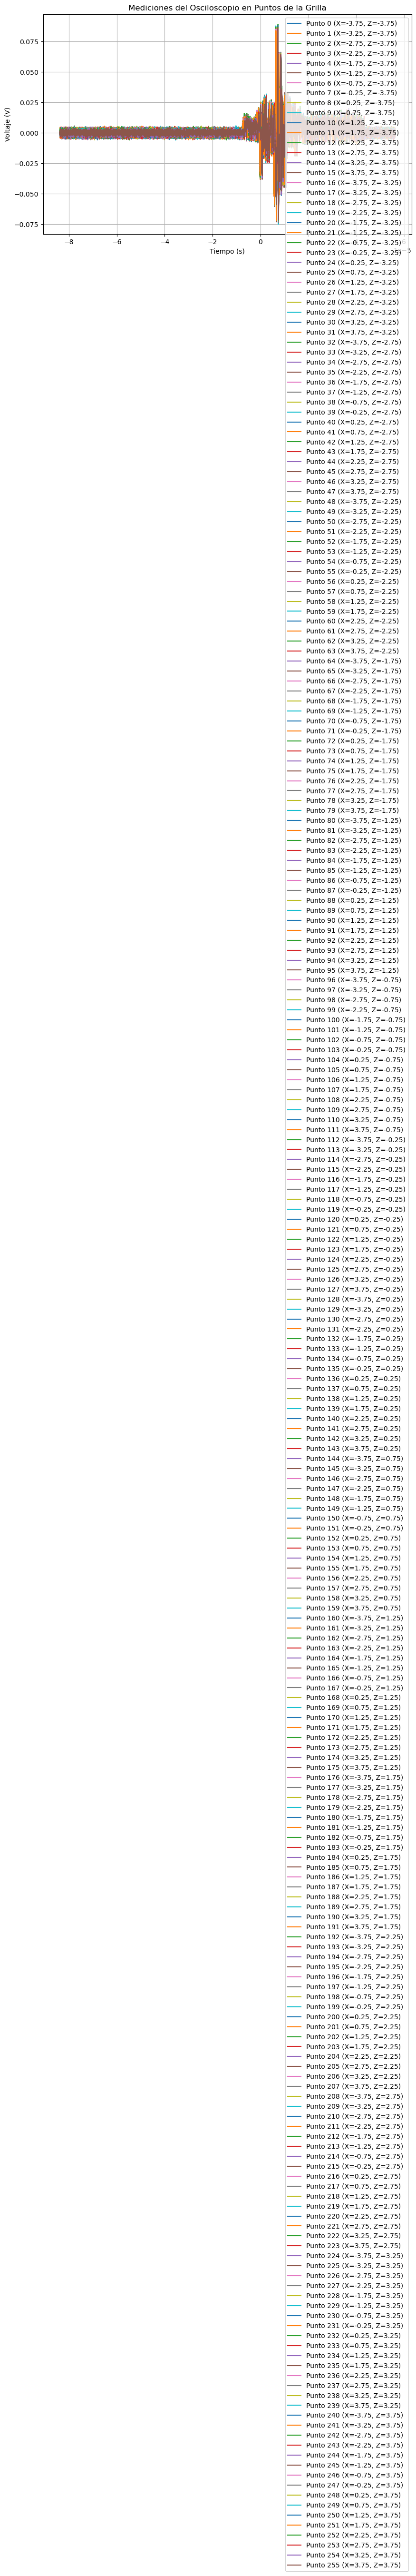

In [58]:
# Graficar mediciones del osciloscopio superpuestas en un mismo gráfico
# leyenda con índice de punto y coordenadas

# Lectura de archivo de historial de movimientos de history_file para extraer coordenadas de cada punto medido y mostrarlas en la leyenda
history_file = Path("motor_history.json")
with open(history_file, 'r') as f:
    history = [json.loads(line) for line in f]
point_coords = {}
for entry in history:
    if entry["event"] == "scan_grid_point":
        point_coords[entry["index"]] = (entry["x"], entry["y"])

plt.figure(figsize=(10, 6))
for i, (t, v) in enumerate(zip(tmeas, vmeas)):
    #plt.plot(t, v)
    plt.plot(t, v, label=f"Punto {i} (X={point_coords.get(i, (0, 0))[0]:.2f}, Z={point_coords.get(i, (0, 0))[1]:.2f})")
plt.title("Mediciones del Osciloscopio en Puntos de la Grilla")
plt.xlabel("Tiempo (s)")
plt.ylabel("Voltaje (V)")
plt.legend()
plt.grid()


## 20. Revisar archivos de estado e historial

Permite verificar qué quedó guardado en `motor_state.json` y las últimas líneas del historial.

In [61]:
print("Estado actual:")
print(Path("motor_state.json").read_text(encoding="utf-8"))

print("\nÚltimos eventos:")
history = Path("motor_history.json")
if history.exists():
    lines = history.read_text(encoding="utf-8").splitlines()
    for line in lines[-10:]:
        print(line)

Estado actual:
{
  "home": {
    "x": 0.0,
    "y": 0.0,
    "z": 0.0
  },
  "position": {
    "x": 0.0,
    "y": 0.0,
    "z": 0.0
  },
  "limits": {
    "x_min": -5.0,
    "x_max": 5.0,
    "y_min": -5.0,
    "y_max": 5.0,
    "z_min": -5.0,
    "z_max": 5.0
  },
  "limits_enabled": true,
  "updated_at": "2026-05-21T18:19:46Z"
}

Últimos eventos:
{"ts": "2026-05-21T18:18:45Z", "event": "move_absolute", "x": 2.25, "y": 3.75, "z": 0.0, "feed": 50.0}
{"ts": "2026-05-21T18:18:45Z", "event": "scan_grid_point", "index": 252, "x": 2.25, "y": 3.75, "z": 0.0}
{"ts": "2026-05-21T18:18:59Z", "event": "move_absolute", "x": 2.75, "y": 3.75, "z": 0.0, "feed": 50.0}
{"ts": "2026-05-21T18:18:59Z", "event": "scan_grid_point", "index": 253, "x": 2.75, "y": 3.75, "z": 0.0}
{"ts": "2026-05-21T18:19:13Z", "event": "move_absolute", "x": 3.25, "y": 3.75, "z": 0.0, "feed": 50.0}
{"ts": "2026-05-21T18:19:13Z", "event": "scan_grid_point", "index": 254, "x": 3.25, "y": 3.75, "z": 0.0}
{"ts": "2026-05-21T18:19:

## 22. Cerrar puerto serie

Cerrar el puerto al finalizar para que pueda usarlo UGS u otra aplicación.

In [62]:
ser.close()
print("Puerto cerrado")

Puerto cerrado
